# Clustering

Every model so far has been handed the right answer. But picture being a buyer in front of a rail of unlabelled samples - no tags, no categories, just pieces - and having to find the natural families hiding in there. That is clustering, and it is such a real part of actually working with clothes. Here I let K-Means group the garments entirely on its own, and then I sneak a look at the labels I had hidden, to see how close its instincts came to ours.

In [8]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

SEED = 42
np.random.seed(SEED)
DATA, RESULTS = Path("data"), Path("results")
RESULTS.mkdir(exist_ok=True)
plt.rcParams.update({"axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False, "font.size": 11})

npz = np.load(DATA / "fashion_mnist_subset.npz", allow_pickle=True)
images = npz["X_train"]
X = images.reshape(len(images), -1).astype(float) / 255.0
y_true = npz["y_train"]
class_names = list(npz["class_names"])

# PCA preprocessing 
from sklearn.decomposition import PCA
Xp = PCA(n_components=50, random_state=SEED).fit_transform(X)
print("clustering features:", Xp.shape)

clustering features: (6000, 50)


## 1. K-Means from scratch

K-Means partitions points into $K$ clusters to minimise the within-cluster sum of squares (also called inertia):

$$
J = \sum_{k=1}^{K} \sum_{x \in C_k} \lVert x - \mu_k \rVert^2, \qquad \mu_k = \frac{1}{|C_k|}\sum_{x \in C_k} x.
$$

Lloyd's algorithm alternates two steps until the assignments stop changing:
1. Assign each point to its nearest centroid.
2. Update each centroid to the mean of its assigned points.

This is coordinate descent on $J$, so $J$ never increases - but it only finds a local optimum, so we use k-means++ seeding (spread the initial centroids out) and keep the best of several restarts.

In [9]:
def _sq_dists(X, C):
    '''Squared Euclidean distances between every row of X and every centroid in C.'''
    return (X**2).sum(1)[:, None] - 2 * X @ C.T + (C**2).sum(1)[None, :]

class KMeans:
    '''K-Means with k-means++ initialisation and multiple restarts.'''
    def __init__(self, n_clusters, n_init=6, max_iter=100, tol=1e-4, seed=SEED):
        self.k, self.n_init, self.max_iter, self.tol, self.seed = \
            n_clusters, n_init, max_iter, tol, seed

    def _kpp_init(self, X, rng):
        centers = [X[rng.integers(len(X))]]
        for _ in range(1, self.k):
            # clip tiny negative values that floating-point can produce in _sq_dists
            d2 = np.maximum(_sq_dists(X, np.array(centers)).min(axis=1), 0.0)
            total = d2.sum()
            probs = d2 / total if total > 0 else np.full(len(X), 1.0 / len(X))
            centers.append(X[rng.choice(len(X), p=probs)])
        return np.array(centers)

    def _one_run(self, X, rng):
        C = self._kpp_init(X, rng)
        for _ in range(self.max_iter):
            labels = _sq_dists(X, C).argmin(axis=1)
            newC = np.array([X[labels == j].mean(axis=0) if np.any(labels == j) else C[j]
                             for j in range(self.k)])
            shift = np.linalg.norm(newC - C)
            C = newC
            if shift < self.tol:
                break
        inertia = float(np.maximum(_sq_dists(X, C)[np.arange(len(X)), labels], 0.0).sum())
        return labels, C, inertia

    def fit(self, X):
        X = np.asarray(X, float)
        best = None
        for i in range(self.n_init):
            res = self._one_run(X, np.random.default_rng(self.seed + i))
            if best is None or res[2] < best[2]:
                best = res
        self.labels_, self.cluster_centers_, self.inertia_ = best
        return self

    def predict(self, X):
        return _sq_dists(np.asarray(X, float), self.cluster_centers_).argmin(axis=1)

km = KMeans(n_clusters=10).fit(Xp)
print(f"our inertia (k=10): {km.inertia_:.1f}")

from sklearn.cluster import KMeans as SkKMeans
sk = SkKMeans(n_clusters=10, n_init=6, random_state=SEED).fit(Xp)
print(f"scikit-learn inertia: {sk.inertia_:.1f}  (within a few % is expected)")

our inertia (k=10): 136230.7
scikit-learn inertia: 136801.0  (within a few % is expected)


## 2. How many clusters? The elbow method

Inertia always drops as $K$ grows (more centroids fit tighter), so we look for the elbow - the $K$ after which extra clusters buy little. We sweep $K = 2 \dots 10$.

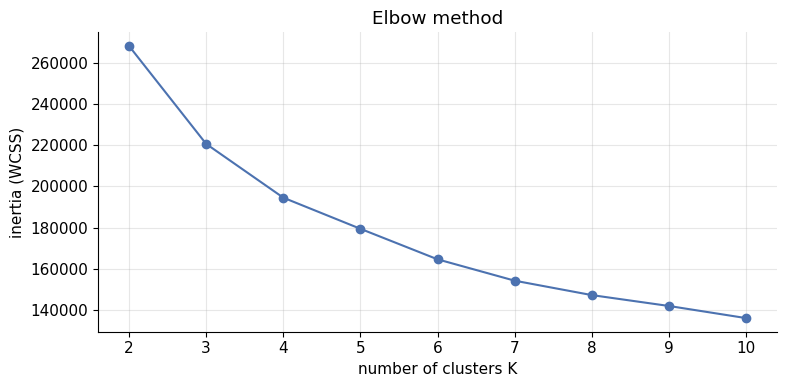

In [10]:
Ks = range(2, 11)
inertias = [KMeans(n_clusters=k, n_init=4).fit(Xp).inertia_ for k in Ks]
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(list(Ks), inertias, "o-", color="#4C72B0")
ax.set_title("Elbow method"); ax.set_xlabel("number of clusters K"); ax.set_ylabel("inertia (WCSS)")
plt.tight_layout(); plt.show()

## 3. Silhouette score (from scratch)

The silhouette score judges clustering quality without labels. For a point $i$ let $a(i)$ be its mean distance to the other points in its own cluster, and $b(i)$ the mean distance to the nearest other cluster. Then

$$
s(i) = \frac{b(i) - a(i)}{\max\{a(i), b(i)\}} \in [-1, 1],
$$

close to $1$ when a point sits comfortably in its cluster and far from others. We average $s(i)$ over a random subsample (the full $n^2$ distance matrix would be wasteful).

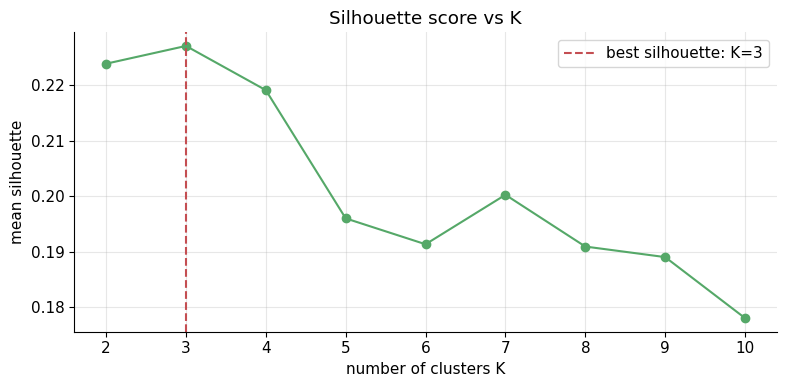

silhouette by K: {2: 0.224, 3: 0.227, 4: 0.219, 5: 0.196, 6: 0.191, 7: 0.2, 8: 0.191, 9: 0.189, 10: 0.178}


In [11]:
def silhouette_score(X, labels, sample=1200, seed=SEED):
    '''Mean silhouette coefficient over a random subsample of points.'''
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(X), size=min(sample, len(X)), replace=False)
    Xs, ls = X[idx], np.asarray(labels)[idx]
    D = np.sqrt(np.maximum(_sq_dists(Xs, Xs), 0))
    uniq = np.unique(ls)
    s = np.zeros(len(Xs))
    for i in range(len(Xs)):
        same = ls == ls[i]
        same[i] = False
        a = D[i, same].mean() if same.any() else 0.0
        b = min(D[i, ls == c].mean() for c in uniq if c != ls[i])
        s[i] = (b - a) / max(a, b) if max(a, b) > 0 else 0.0
    return float(s.mean())

sils = [silhouette_score(Xp, KMeans(n_clusters=k, n_init=4).fit(Xp).labels_) for k in Ks]
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(list(Ks), sils, "o-", color="#55A868")
best_k = list(Ks)[int(np.argmax(sils))]
ax.axvline(best_k, ls="--", color="#C44E52", label=f"best silhouette: K={best_k}")
ax.set_title("Silhouette score vs K"); ax.set_xlabel("number of clusters K")
ax.set_ylabel("mean silhouette"); ax.legend()
plt.tight_layout(); plt.show()
print("silhouette by K:", {k: round(s, 3) for k, s in zip(Ks, sils)})

The elbow and the silhouette do not quite agree, and I think that honesty is the interesting part: the silhouette prefers a few broad families, because at the coarsest level the strongest story in the pixels really is just footwear vs. clothing vs. bags. Since I want to compare against the ten categories I know are in there, the rest of the notebook clusters at $K = 10$.

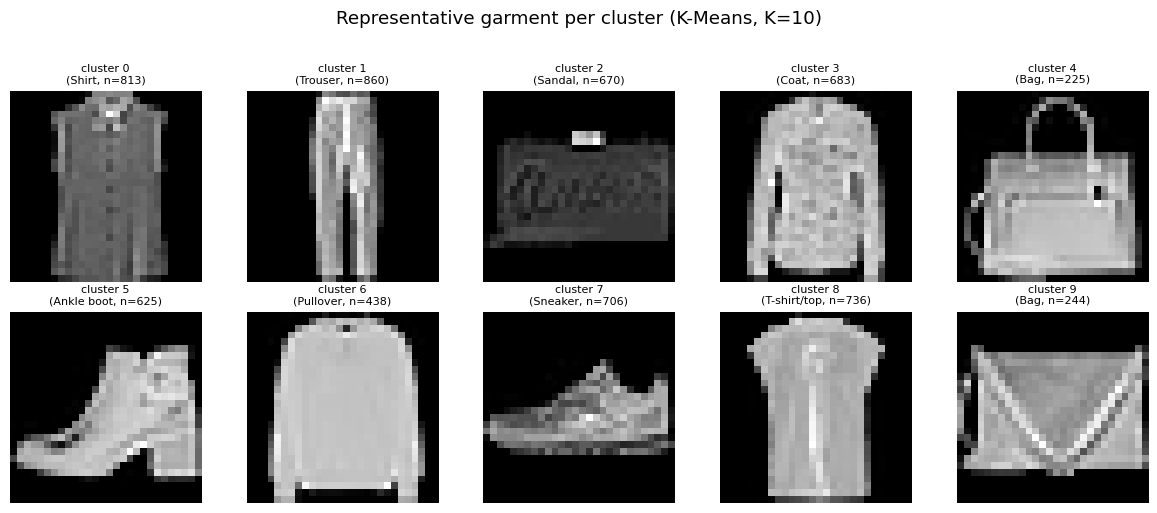

In [12]:
# Cluster at K=10 and show the garment closest to each cluster centre — the "archetype".
km10 = KMeans(n_clusters=10).fit(Xp)
labels = km10.labels_

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for c, ax in enumerate(axes.ravel()):
    members = np.where(labels == c)[0]
    d = _sq_dists(Xp[members], km10.cluster_centers_[c][None, :]).ravel()
    rep = members[d.argmin()]
    ax.imshow(images[rep], cmap="gray"); ax.axis("off")
    top_label = class_names[np.bincount(y_true[members]).argmax()]
    ax.set_title(f"cluster {c}\n({top_label}, n={len(members)})", fontsize=8)
fig.suptitle("Representative garment per cluster (K-Means, K=10)", y=1.02)
plt.tight_layout(); plt.show()

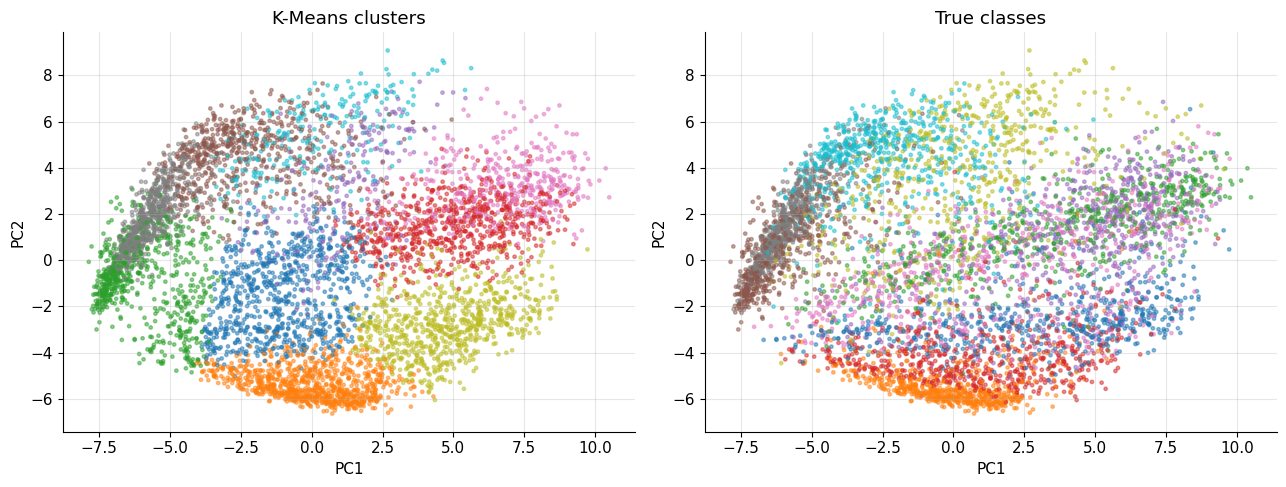

In [13]:
# preview
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
ax[0].scatter(Xp[:, 0], Xp[:, 1], c=labels, cmap="tab10", s=6, alpha=0.5)
ax[0].set_title("K-Means clusters"); ax[0].set_xlabel("PC1"); ax[0].set_ylabel("PC2")
ax[1].scatter(Xp[:, 0], Xp[:, 1], c=y_true, cmap="tab10", s=6, alpha=0.5)
ax[1].set_title("True classes"); ax[1].set_xlabel("PC1"); ax[1].set_ylabel("PC2")
plt.tight_layout(); plt.show()

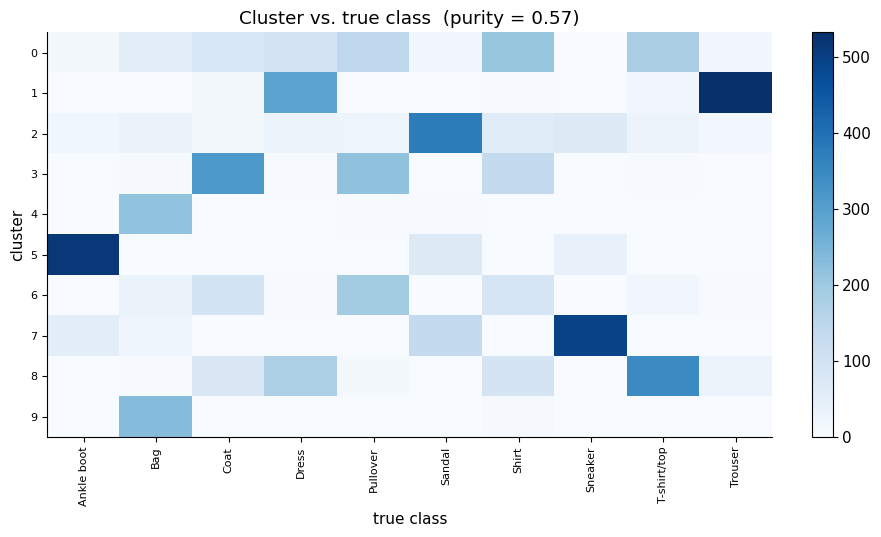

clustering purity at K=10: 0.570


In [14]:
# cross-tabulate clusters against hidden labels and measure purity
ct = pd.crosstab(pd.Series(labels, name="cluster"),
                 pd.Series([class_names[i] for i in y_true], name="true class"))
purity = ct.max(axis=1).sum() / ct.values.sum()

fig, ax = plt.subplots(figsize=(9, 5.5))
im = ax.imshow(ct.values, cmap="Blues", aspect="auto"); fig.colorbar(im, fraction=0.046)
ax.set_xticks(range(len(ct.columns))); ax.set_xticklabels(ct.columns, rotation=90, fontsize=8)
ax.set_yticks(range(len(ct.index))); ax.set_yticklabels(ct.index, fontsize=8)
ax.set_xlabel("true class"); ax.set_ylabel("cluster")
ax.set_title(f"Cluster vs. true class  (purity = {purity:.2f})"); ax.grid(False)
plt.tight_layout(); plt.show()
print(f"clustering purity at K=10: {purity:.3f}")

In [15]:
# save a summary and run sanity checks
clustering_summary = pd.DataFrame([
    {"metric": "best_k_by_silhouette", "value": best_k},
    {"metric": "best_silhouette", "value": round(max(sils), 4)},
    {"metric": "purity_at_k10", "value": round(float(purity), 4)},
    {"metric": "inertia_k10", "value": round(km10.inertia_, 1)},
])
clustering_summary.to_csv(RESULTS / "clustering_summary.csv", index=False)
print("Saved to results/clustering_summary.csv")

assert inertias[-1] < inertias[0], "inertia should fall as K grows from 2 to 10"
assert -1.0 <= max(sils) <= 1.0
assert 0.0 <= purity <= 1.0 and purity > 0.4, "purity should be clearly above chance (0.1)"
print("sanity check")
clustering_summary

Saved to results/clustering_summary.csv
sanity check


,metric,value
0,best_k_by_silhouette,3.0000
1,best_silhouette,0.2270
2,purity_at_k10,0.5703
3,inertia_k10,136230.7000


## 4. Adjusted Rand Index and cluster stability

Purity has two blind spots: it never penalises splitting one true class across many clusters, and it drifts upward as $K$ grows. The Adjusted Rand Index (ARI) avoids both - it counts the pairs of points that the clustering and the true labels agree to keep together or apart, then corrects for chance, so a random labelling scores about 0 and a perfect one scores 1.Implementing it from scratch and validate against scikit-learn. Then, because K-Means only reaches a *local* optimum, I re-run it from several seeds to see how stable the recovered structure really is.

our ARI (K=10) = 0.3669   scikit-learn = 0.3669


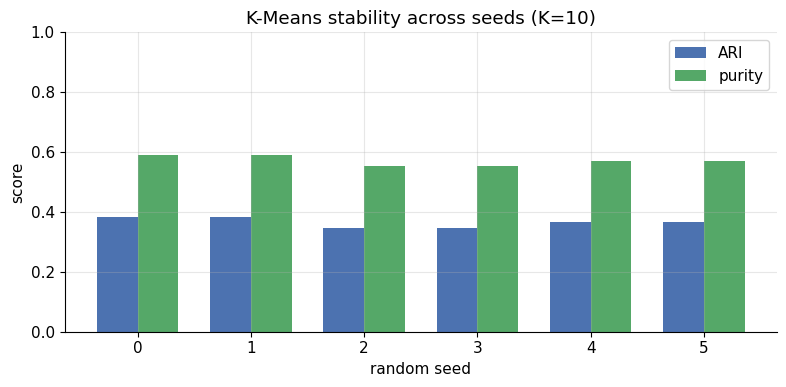

ARI across seeds:    mean = 0.3652, std = 0.0175
purity across seeds: mean = 0.5711, std = 0.0173


In [16]:
# adjusted Rand Index from scratch (pair-counting), validated against scikit-learn.
from math import comb
def adjusted_rand_index(labels_true, labels_pred):
    ct = pd.crosstab(pd.Series(labels_true), pd.Series(labels_pred)).values
    sum_ij = sum(comb(int(n), 2) for n in ct.ravel())
    a = sum(comb(int(n), 2) for n in ct.sum(axis=1))
    b = sum(comb(int(n), 2) for n in ct.sum(axis=0))
    expected = a * b / comb(int(ct.sum()), 2)
    return (sum_ij - expected) / (0.5 * (a + b) - expected)

from sklearn.metrics import adjusted_rand_score
ari = adjusted_rand_index(y_true, labels)
print(f"our ARI (K=10) = {ari:.4f}   scikit-learn = {adjusted_rand_score(y_true, labels):.4f}")

# stability: cluster at K=10 from several seeds and report the spread of ARI / purity.
def purity_of(lab):
    ct = pd.crosstab(pd.Series(lab), pd.Series(y_true))
    return float(ct.max(axis=1).sum() / ct.values.sum())

rows = []
for s in range(6):
    km_s = KMeans(n_clusters=10, n_init=4, seed=s).fit(Xp)
    rows.append({"seed": s, "ARI": adjusted_rand_index(y_true, km_s.labels_),
                 "purity": purity_of(km_s.labels_), "inertia": km_s.inertia_})
stability = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(stability["seed"] - 0.18, stability["ARI"], width=0.36, label="ARI", color="#4C72B0")
ax.bar(stability["seed"] + 0.18, stability["purity"], width=0.36, label="purity", color="#55A868")
ax.set_title("K-Means stability across seeds (K=10)"); ax.set_xlabel("random seed")
ax.set_ylabel("score"); ax.set_ylim(0, 1); ax.legend()
plt.tight_layout(); plt.show()
print(f"ARI across seeds:    mean = {stability['ARI'].mean():.4f}, std = {stability['ARI'].std():.4f}")
print(f"purity across seeds: mean = {stability['purity'].mean():.4f}, std = {stability['purity'].std():.4f}")

ARI is far blunter than purity, and that is the point: it refuses to reward clusters merely for being numerous, so the honest agreement with the true categories sits below what the 0.57 purity suggested - while still landing clearly above the ~0 a random grouping would earn. Across seeds the scores barely move, so k-means++ with a few restarts keeps finding essentially the same structure: it is a stable property of the data, not an artefact of one lucky start.